# **Imports**

In [394]:
from libs.TorretaMedicion import TorretaMedicion
import matplotlib.pyplot as plt
import time

import numpy as np
from libs.FuncionesProcesamiento import *

import pandas as pd
import os
import re
from datetime import datetime
import json

# **Objeto Básico y Variables**

In [395]:
rango_barrido = [0, 183]
paso_barrido = 3


# **Barrido**

In [396]:
mi_robot = TorretaMedicion(_puerto= "COM12")


# Inicializo kalman
mi_robot.set_kalman_filter()
angle_vect = []


mi_robot.send_command("RX_MOV_SERVO",[rango_barrido[0]]) 
time.sleep(2)
for angle in range(rango_barrido[0],rango_barrido[1],paso_barrido):
    angle_vect.append(angle)
    mi_robot.send_command("RX_MOV_SERVO",[angle]) 
    mi_robot.send_command("RX_MS_SENSOR_ULTRA_SONIDO_ONETIME")
    mi_robot.send_command("RX_MS_SENSOR_OPTICO_ONETIME")

time.sleep(2)
sensor_us_values = mi_robot.get_sensor_ultrasonido().get_values()
#time.sleep(2)
sensor_opt_values = mi_robot.get_sensor_optico().get_values()
#time.sleep(2)
mi_robot.kf.update_kalman_filter()
valores_kalman = np.array(mi_robot.kf.kalman_sensor.get_values())

mi_robot.disconnect()

angle_vect = [c-rango_barrido[0] for c in angle_vect ]

# **Gráfico**

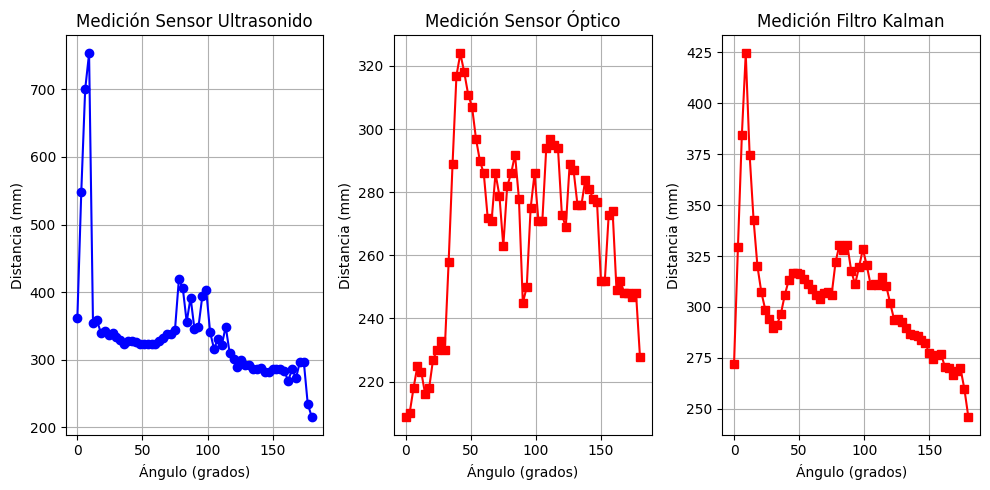

In [397]:
plt.figure(figsize=(10, 5))

# Gráfico para sensor ultrasonido
plt.subplot(1, 3, 1)
plt.plot(angle_vect,sensor_us_values, marker='o', color='b')
plt.title('Medición Sensor Ultrasonido')
plt.xlabel('Ángulo (grados)')
plt.ylabel('Distancia (mm)')
plt.grid(True)

# Gráfico para sensor óptico
plt.subplot(1, 3, 2)
plt.plot(angle_vect,sensor_opt_values, marker='s', color='r')  
plt.title('Medición Sensor Óptico')
plt.xlabel('Ángulo (grados)')
plt.ylabel('Distancia (mm)')
plt.grid(True)

# Gráfico kalman
plt.subplot(1, 3, 3)
plt.plot(angle_vect,valores_kalman, marker='s', color='r')  
plt.title('Medición Filtro Kalman')
plt.xlabel('Ángulo (grados)')
plt.ylabel('Distancia (mm)')
plt.grid(True)

plt.tight_layout()
plt.show()


# **Guardado en .CSV**

In [398]:
# === Vectores de medición ===
ang = np.array(angle_vect)
us = np.array(sensor_us_values)
ir = np.array(sensor_opt_values)
kal = np.array(valores_kalman)

# Normalizar longitudes
min_len = min(len(ang), len(us), len(ir), len(kal))
ang, us, ir, kal = ang[:min_len], us[:min_len], ir[:min_len], kal[:min_len]

# Carpeta destino
out_dir = "E:\\Agustin\\Escritorio\\Mapeo-por-imagen_GIAR\\Dataset\\26_05_11\\csv_sensores"
os.makedirs(out_dir, exist_ok=True)

# === Buscar el próximo ID disponible ===
existing_ids = []
for fname in os.listdir(out_dir):
    if fname.endswith(".csv"):
        try:
            existing_ids.append(int(fname.replace(".csv","")))
        except:
            pass

next_id = max(existing_ids) + 1 if existing_ids else 1

# === Fecha ===
fecha_str = datetime.now().isoformat()

# === Crear fila ===
df = pd.DataFrame([{
    "id": next_id,
    "fecha": fecha_str,
    "angulo": json.dumps(ang.tolist()),
    "ultrasonico": json.dumps(us.tolist()),
    "infrarrojo": json.dumps(ir.tolist()),
    "kalman": json.dumps(kal.tolist())
}])

# === Guardar CSV de esta medición ===
filename = f"{next_id}.csv"
filepath = os.path.join(out_dir, filename)

df.to_csv(filepath, index=False)

print(f"Batch guardado en: {filepath}")


Batch guardado en: E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\Dataset\26_05_11\csv_sensores\56.csv


# **Verificacion**

In [399]:
def plot_medicion_radial(csv_path):
    """
    Abre un archivo CSV de medición y grafica en forma radial (polar)
    las mediciones de infrarrojo y ultrasónico usando el vector de ángulos.
    """
    
    # Leer CSV
    df = pd.read_csv(csv_path)
    
    # Cargar vectores desde JSON
    ang = np.array(json.loads(df.loc[0, "angulo"]))
    us  = np.array(json.loads(df.loc[0, "ultrasonico"]))
    ir  = np.array(json.loads(df.loc[0, "infrarrojo"]))
    kal = np.array(json.loads(df.loc[0, "kalman"]))

    # Convertir ángulos a radianes
    theta = np.deg2rad(ang)

    # Crear figura polar
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, projection='polar')

    # Graficar
    ax.plot(theta, us, label="Ultrasónico")
    ax.plot(theta, ir, label="Infrarrojo")
    ax.plot(theta, kal, label="Kalman")
    
    # Opciones de estilo
    ax.set_title("Mediciones radiales (US / IR)")
    #ax.set_theta_zero_location("W")   # 0° arriba
    #ax.set_theta_direction(-1)        # ángulos en sentido horario
    ax.set_ylim(top=550)
    ax.legend(loc="lower right")
    plt.show()


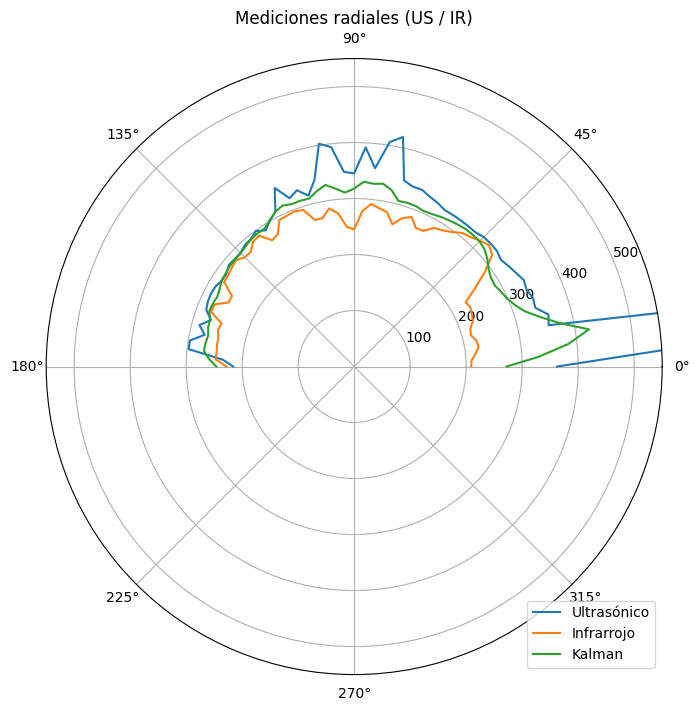

In [400]:
plot_medicion_radial(f"{out_dir}//{next_id}.csv")
